# Day 11 Recap, Resume _About Vectors_ (11 December 2025)

It has been a little over a month since I started my adventure. I am happy because I am busy. I have learned some Python, albeit slowly. I spent some time setting up the blog, but GitHub workflow (Actions) and ChatGPT failed me. I have given up on them and will 

1) Keep doing "core" notebooks (such as this one). They are expected to act like reminders or memory cues. I am applying to my learning what the great mathematician Bill Thurston said of mathematics:
> Mathematics is amazingly compressible: you may struggle a long time, step by step, to work through some process or idea from several approaches. **But once you really understand it and have the mental perspective to see it as a whole, there is often a tremendous mental compression**. You can file it away, recall it quickly and completely when you need it, and use it as just one step in some other mental
process. The insight that goes with this compression is one of the real joys of
mathematics.

2) Keep writing notebooks as blog posts once in a while.

Discussions with ChatGPT have been invaluable. I am still months away from _Thinking in Idiomatic Python_, but I am optimistic about getting there. For now, I am returning to Banesh Hoffmann's book. I will then do Linear Algebra. I will continue exploring Martelli's book and writing [programs](https://github.com/kedarmhaswade/yakk-2/tree/main/programs).

# Chapter 2: Algebraic Notation and Basic Ideas

## 1. Equality and Addition
> Let us agree to say that two vectors, $\vec{U}$ and $\vec{V}$, **are equal if they have equal magnitudes, identical directions, and a common starting point, and represent types of entities that can combine according to the parallelogram law**. If they are _free vectors_ (such as displacement), we need not insist that they have a common starting point:

$$
\begin{equation}
\vec{OA}=\vec{OB}, \text{ or } \vec{\mathbb{U}}=\vec{\mathbb{V}}
\end{equation}
\tag{1.1}
$$

> We shall also use this symbol = in the broader sense of "equivalent to".

> Let us agree to assume that vectors in a given problem or discussion *can combine* unless the contrary is either obvious or else explicitly stated. For example, two displacements can combine, but a force and a displacement cannot.

## Exercise 1.2
If $\vec{\mathbb{U}}$ and $\vec{\mathbb{V}}$ have the same starting point and the same direction, show that the magnitude of their resultant is $\mathbb{U} + \mathbb{V}$.
### My Solution 1.2
Showing something can often be challenging in an open area of mathematics. If we assume the axiomatic method, the axioms need to be stated. In a way, we ask ourselves, "Where do I begin?"

I am going to assume Euclidean geometry in space. Therefore, one axiom is that a plane passes through two given vectors. 

Then, we can consider using the Law of Cosines. 

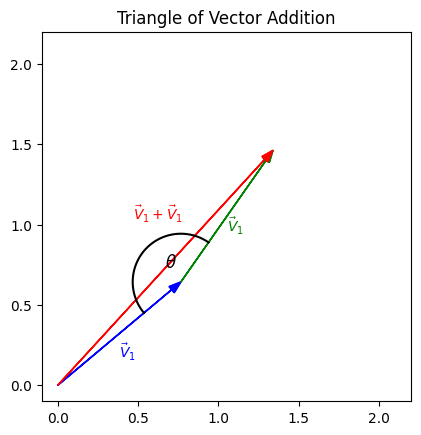

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Two nearly-parallel vectors of equal magnitude
# Let magnitude = 1
angle1 = np.deg2rad(40)    # v1 direction
angle_diff = np.deg2rad(15)  # small difference between the vectors

v1 = np.array([np.cos(angle1), np.sin(angle1)])
v2 = np.array([np.cos(angle1 + angle_diff), np.sin(angle1 + angle_diff)])

# Resultant
R = v1 + v2

# Plot setup
fig, ax = plt.subplots()
ax.set_aspect('equal', adjustable='box')

# Draw v1 (tail at origin)
ax.arrow(0, 0, v1[0], v1[1],
         head_width=0.05, length_includes_head=True, color='blue')

# Draw v2 (tail at head of v1)
ax.arrow(v1[0], v1[1], v2[0], v2[1],
         head_width=0.05, length_includes_head=True, color='green')

# Draw resultant R
ax.arrow(0, 0, R[0], R[1],
         head_width=0.05, length_includes_head=True, color='red')

# Draw v1 from origin
ax.arrow(0, 0, v1[0], v1[1],
         head_width=0.05, length_includes_head=True, color='blue')

# Draw v2 from the head of v1
tail2 = v1
ax.arrow(tail2[0], tail2[1], v2[0], v2[1],
         head_width=0.05, length_includes_head=True, color='green')

# Draw resultant
ax.arrow(0, 0, R[0], R[1],
         head_width=0.05, length_includes_head=True, color='red')

# ---- Angle at the joint: nearly pi radians ----
# Draw arc at tail2 (head of v1)
theta = np.linspace(angle1 + np.pi, angle1 + angle_diff, 200)
arc_radius = 0.3
x_arc = tail2[0] + arc_radius * np.cos(theta)
y_arc = tail2[1] + arc_radius * np.sin(theta)

ax.plot(x_arc, y_arc, color='black')

# Label angle: approx pi - angle_diff
obtuse_angle_deg = 180 - np.rad2deg(angle_diff)
mid_theta = (angle1 + np.pi + (angle1 + angle_diff)) / 2

ax.text(tail2[0] + 0.45 * arc_radius * np.cos(mid_theta),
        tail2[1] + 0.45 * arc_radius * np.sin(mid_theta),
        rf"$\theta$",
        fontsize=12)
# Styling
ax.set_xlim(-0.1, 2.2)
ax.set_ylim(-0.1, 2.2)
ax.set_title("Triangle of Vector Addition")

# Labels
ax.text(v1[0]/2, v1[1]/2 - 0.15, r'$\vec{V}_1$', color='blue')
ax.text(v1[0] + v2[0]/2, v1[1] + v2[1]/2 - 0.1, r'$\vec{V}_1$', color='green')
ax.text(R[0]/2-0.2, R[1]/2 + 0.3, r'$\vec{V}_1 + \vec{V}_1$', color='red')

plt.show()


Now, using the Law of Cosines, we can say that $R^2=V_1^2+V_1^2-2V_1V_1\cos\theta=V_1^2+V_1^2-2V_1^2\cos\theta$.

As $\theta$ approaches $\pi^c$, there is only one value that $R^2$ approaches, and that is $2V_1^2-2V_1^2(\cos\pi)=2V_1^2-2V_1^2(-1)=4V_1^2$

Therefore, $R\to V_1+V_1=2 V_1$. Note that $V_1$ is only a real number (scalar), not a vector. We can use the real number rule, $x+x=2\times x=2x\forall x\in\mathbb{R}$. Thus, the resultant is a vector whose magnitude is twice that of each vector being combined.

## 2. Multiplication by Numbers (Scalars)
With various examples, Hoffmann says
> If $h$ is a positive number, we write $h\vec{\mathbb{V}}$ for the vector that is identical with $\vec{\mathbb{V}}$ except that its magnitude is $h$ times that of $\vec{\mathbb{V}}$.

The discussion refers to rational and irrational numbers. With rational numbers (fractions), what $\overrightarrow{\frac{a}{b}\mathbb{V}}\mid a,b\in\mathbb{N}, b\ne 0$ means is clear because with two vectors $\vec{\mathbb{U}},\vec{\mathbb{V}}$ of the same direction (but not necessarily equal magnitudes), we can imagine two vectors $\overrightarrow{a\mathbb{V}}$ and $\overrightarrow{b\mathbb{U}}$ that are "equal" (same direction and magnitude).

Irrationals are trickier. Perhaps we can only approximate a vector $\overrightarrow{\alpha\mathbb{V}}$ where $\alpha$ is an irrational number.

Hoffmann asks a few pretty straightforward exercises. Multiplying a vector by a scalar is also called _scaling_ the vector.

## 3. Subtraction
> Having managed to relate the symbol $+$ to the parallelogram law without doing violence to its usual arithmetical meaning, we wonder whether we can be as successful with the symbol $-$. It turns out that we can!

> If $\overrightarrow{\mathbb{V}}$ is a vector, we define its negative, which we write $\overrightarrow{\mathbb{-V}}$, as a vector identical with it except that it points in the opposite direction. Thus, in Figure 3.1, if U is V turned through $180^\circ$, then $\overrightarrow{\mathbb{U}}=\overrightarrow{\mathbb{-V}}$. Note that $\overrightarrow{\mathbb{V}}$ and $\overrightarrow{\mathbb{-V}}$ have the same magnitude: **the magnitude is always taken to be positive (when it is not zero, of course)**. To consolidate the link between the arithmetical and vectorial uses of the symbol $-$, we define $\overrightarrow{(-h)\mathbb{V}}$ for positive $h$ as $\overrightarrow{h(\mathbb{-V})}$ (where $h\in\mathbb{R}$.
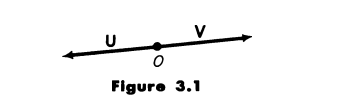

**Introducing Unit Vectors here may be useful.** Also, "time" is considered a scalar, although it has a direction: forward. Thus, when we divide a vector by a number, we get a scaled vector in the same or the opposite direction.

## 4. Speed and Velocity
We learned in grade school that when we divide _distance_ by time (distance traveled per unit time), we get _speed_ (an elusive concept since Zeno of Elea, understood only after Weierstrass formulated calculus in the late nineteenth century). 

Distance is a scalar, and so is Speed. We take _time_ as a scaling factor of two numbers in this case. There is no regard for direction. 

Displacement is a vector, and so is Velocity. Here too, _time_ is a scalar, and we get two vectors that are scaled versions of each other: Displacement and Velocity. Since Displacement is a _free vector_ (the starting point does not matter), so is Velocity.

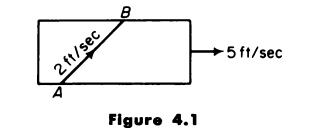

> Figure 4.1 shows a platform with a line AB marked on it. Suppose a point moves uniformly along this line from A to B at 2 ft/sec, and that the platform moves uniformly to the east at 5 ft/sec relative to the ground. Then the point is being subjected to two different velocities simultaneously. **But it does not, therefore, move relative to the ground in two different directions at once.** To say that it did would be to speak nonsense (except, perhaps, if we were talking of quantum phenomena, which we are not). It would remind us of the humorist Stephen Leacock's famous account of the angry man who "flung himself from the room, flung himself upon his horse, and rode madly off in all directions."
> **How does the point actually move**? We can find out by considering what happens in one second. For convenience, let us assume that AB is 2 ft long, so that in one second the point moves from A to B. During this second, the platform moves 5 ft to the east (relative to the ground), and the ends of the line AB drawn on it move to new positions, A', B', that are 5 ft to the east of their original positions, as in Figure 4.2. The moving point travels from A to B' relative to the ground.

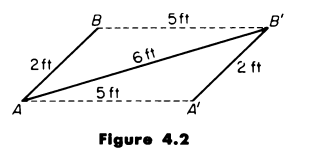

> The distance AB' depends on the angle BAA'; for simplicity, let us assume it is 6 ft. **It is easy to see that the point travels from A to B' in a straight line, with uniform speed relative to the ground**.

## Exercise 4.1 
Prove this. (To get the idea, consider first what happens in, say, 1 second, using similar triangles. Then consider what happens in $t$ seconds.)
### My Solution 4.1
By "this" he means the assertion that point A travels from A to B' in a straight line. As the hint says, we can imagine the situation after 0.5 sec, 0.1 sec, or even a millionth of a second after everything is set in motion. All these triangles, constructed by vectors representing the velocities and their resultants (one along AA', another along AB, and the resultant along AB'), are similar. This means all reincarnations of point B' lie on a straight line. It's almost as if the point has a mind of its own, and it starts moving in the direction AB' right from the word go!

## Exercise 4.3
A train is going at 50 mph due north, and a fly in one of the compartments flies at 20 mph northeast relative to the compartment. Find, by means of an accurate diagram, the actual velocity of the fly relative to the rails.
### My Solution 4.3
It can be shown that the resultant is $55.15$ mph about $55.5^\circ$ north of east.

## Exercise 4.9
A gun mounted on a train is pointed vertically upward. The train moves horizontally due east at 80 mph. And the gun fires a bullet with a muzzle velocity of 80 mph. What is the velocity of the bullet relative to the ground?
### My Solution 4.9
Of course, $80\sqrt{2}$ mph northeast.

## Exercise 4.10
Rain is falling vertically with a speed of $u$ ft/sec. At what angle does it appear to be falling as viewed from a train moving horizontally at $v$ ft/sec?
### My Solution 4.10
This is an often-experienced scenario. You are driving, and it's raining. Your wipers are on. There are signals on the road. As soon as you pick up the speed, the wipers (assuming they are not adaptive, but oscillate at a uniform angular speed) appear to be doing more work. That is, they seem to be wiping more rainwater, even when the rain is uniform. 

I am so glad to see this exercise. I have often wondered about this experience. I reasoned like this: If the rain is falling vertically down at a constant speed, the amount of rainwater must be uniform, _regardless of the car's speed_. 

However, this is _not_ the case. The rain comes _vertically down relative to the ground_. My car moves horizontally relative to the ground (at different speeds; it stops at lights, accelerates, etc.) But we want to estimate the velocity of the falling rain relative to the car.

At first, let the car be stationary. The rainwater is moving $u$ m/s due south relative to both the ground and car because it is stationary (it's "one" with the ground).

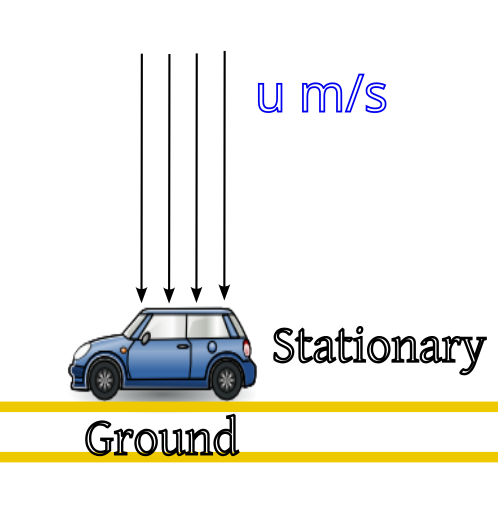

Now, it starts moving due west with a velocity $v$ m/s relative to the ground. This does not affect the velocity of rain relative to the ground. But this does affect the velocity of the rain _perceived_ by the car. 

Since we are inside the car, we want to find the velocities as we perceive them, that is, relative to us! If we are moving $v$ m/s due west relative to the ground, then the ground is moving $v$ m/s due east **relative to us**! 

The picture then becomes like this:
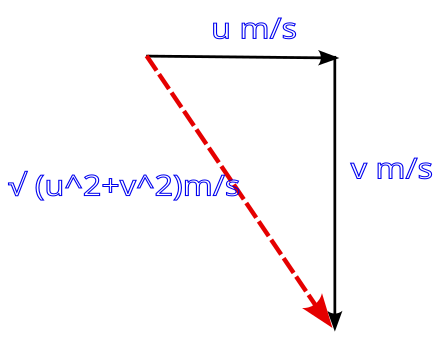

**The car, after picking up speed relative to the ground, indeed perceives that the rain has sped up relative to itself!** The (magnitude of the) velocity of rain as perceived by us inside the car is $\sqrt{u^2+v^2}$, which is larger than both $u$ and $v$. The amount of rainwater collected at the windshield is more, and the wipers have to work harder!

## Exercise 4.11
The wind is blowing steadily from the east at 5 mph. A boat in still water is traveling in a circle, with a constant speed of 5
mph. A pennant (flag) is flying at the top of the mast. Describe in words the way the direction of the pennant changes 
(a) relative to the deck of the boat, and 
(b) relative to the water. 

(It was a situation like this that led the astronomer Bradley to an understanding of the phenomenon of _aberration_, a topic you may find well worth looking into on your own. Note that the velocities in parts (a) and (b) both change.)
### My Solution 4.11
I assume that the radius of the boat's circle is much larger than its dimensions. Thus, when we say that it is traveling in a circle with a constant speed of 5 mph, everything aboard is doing so; the pennant has no circular speed relative to an observer on the deck.

Wind is blowing east to west at 5 mph relative to the still water.

1) Consider the position A1 of the boat. We are on the deck, observing the mast flag. We cannot perceive the boat's tangential velocity because we are on its deck! To us, the flag is just waving to the east, thanks to the wind. And this is the case no matter where the boat is in its orbit.

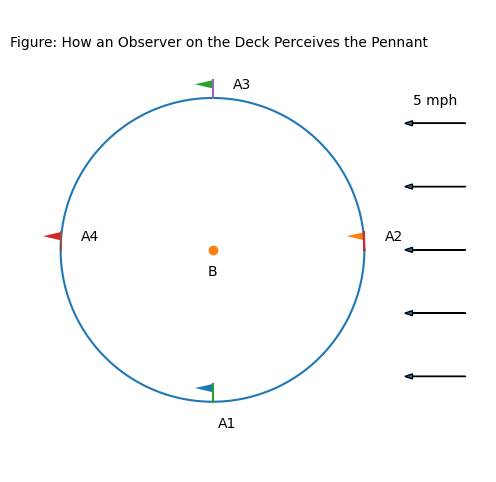

In [43]:
# Thanks to ChatGPT
import matplotlib.pyplot as plt
import numpy as np

# Circle path
theta = np.linspace(0, 2*np.pi, 400)
R = 3
x = R * np.cos(theta)
y = R * np.sin(theta)

plt.figure(figsize=(6,6))
plt.plot(x, y)

# Observer B (center)
plt.plot(0, 0, marker='o', markersize=6)
plt.text(0, -0.3, "B", ha="center", va="top")

# Boat positions and labels in requested order
# A1: bottom (270°), then counterclockwise: 0°, 90°, 180°
angles = [3*np.pi/2, 0, np.pi/2, np.pi]
labels = ["A1", "A2", "A3", "A4"]

for ang, label in zip(angles, labels):
    bx = R * np.cos(ang)
    by = R * np.sin(ang)

    # Mast
    plt.plot([bx, bx], [by, by + 0.35])

    # Flag
    plt.fill(
        [bx, bx - 0.35, bx],
        [by + 0.35, by + 0.27, by + 0.19]
    )

    # Observer label
    if label == "A1":
        # Move below for readability
        plt.text(bx + 0.1, by - 0.3, label, ha="left", va="top")
    else:
        plt.text(bx + 0.4, by + 0.25, label, ha="left", va="center")

    # Tangential velocity direction (unit)
    vx = -np.sin(ang)
    vy =  np.cos(ang)

    # Velocity arrow
    #plt.arrow(
    #    bx, by,
    #    0.8 * vx, 0.8 * vy,
    #    head_width=0.1,
    #    length_includes_head=True
    #)

    # Perpendicular offset for velocity label
    offset = 0.25
    nx = -vy
    ny =  vx

#    plt.text(
#        bx + 0.8 * vx + offset * nx,
#        by + 0.8 * vy + offset * ny,
#        "5 mph",
#        ha="center",
#        va="center"
#    )

# Wind arrows (east to west)
for yy in np.linspace(-2.5, 2.5, 5):
    plt.arrow(5, yy, -1.2, 0, head_width=0.1, length_includes_head=True)

# Wind label
plt.text(4.4, 2.8, "5 mph", ha="center", va="bottom")

# Caption
plt.text(-4, 4, "Figure: How an Observer on the Deck Perceives the Pennant")
plt.axis('equal')
plt.axis('off')
plt.show()


2) To an observer in the still water, it should be a different matter. Consider an observer near A2, but in the water. The boat is moving relative to this observer! She thinks that the flag is still when it is at A1, because it has a tangential velocity equal to the wind's in the opposite direction. Then, it starts waving in a northwestern direction. By the time the boat reaches A2, i.e., the closest to the observer, the flag is moving in the northwest direction. As it leaves A2, it moves less in the northern direction. At A3, it moves fastest directly east. As it leaves A3, it starts moving in a southwestern direction. At A4, it appears to be moving southwest before it starts slowing down. It comes to a stop at A1.

## Exercise 4.12
In Exercise 4.10, if the rain were falling at an angle $\theta$ to the horizontal, show that its apparent direction would make with its actual direction an angle $\arcsin((\frac{u}{v})\sin\theta)$. (Compare this with the astronomical phenomenon of _aberration_, which may be briefly described as follows: To catch the light from a star, a telescope must point in the apparent direction of the incoming light. Consequently, as the earth moves in its orbit, the stars seem to move once a year in tiny ovals (actually ellipses) whose shapes depend on θ, and thus on the positions of the stars.)
### My Solution 4.12
I spent a lot of time on this one. However, what Hoffmann wants us to show is still elusive. I could show $\sin\alpha=\frac{v}{r}\sin\theta$, where $\alpha$ is the angle between the actual and apparent directions of the rain and $r$ is the magnitude of the apparent velocity of the rain. Does $\frac{v}{r}$ equal $\frac{u}{v}$? It seems unlikely. Anyway, I haven't solved this one yet ...

---


It is customary to define velocity as the rate of change of displacement with respect to time (I think of velocity as a _scaled_ displacement because time is a scalar). This makes velocities vectors. 

We have to be careful when combining vectors, however. Vectors must be amenable to combining this way. 

**Only if $\overrightarrow{0.5\mathbb{D}}$ and $\overrightarrow{\frac{1}{3}\mathbb{D}}$ are both velocities can we combine them using the parallelogram law.** We must not add a displacement vector to a velocity vector, even if we think of velocity as scaled displacement.

Hoffmann explains lucidly:

---

I think we simply have to accept the fact that the vectorial concept of average velocity has unpleasant aspects when applied to motion not in a straight line. **When the motion is uniform, the speed is the same at every instant**. When the motion is not uniform, the concept of _instantaneous speed_ is a rather sophisticated one. It involves ideas from the calculus, which we can not discuss here. Roughly speaking, the instantaneous speed is the value that the average speed approaches as the time interval gets smaller (approaches zero). When these ideas are applied to the average velocity, they yield an instantaneous velocity that, except in highly artificial situations, behaves much as one would expect it to behave, and this despite the peculiar characteristics of the average velocity from which it is obtained. The instantaneous velocity is a vector quantity, and its magnitude is the instantaneous speed. **At every instant, it has the direction of the line tangent to the path of the moving point at the instantaneous position of the point**.

---

And then, he leads us into Einstein's theory of relativity. We may miss a lot if we are not paying attention:

---

> There is a subtle difference between the _velocity considered in terms of the moving platform_ and the _velocity defined as the rate of change of displacement with respect to time_.

> Look back at the discussion of the former (Figures 4.1 and 4.2), and at the exercises based on it, and you will see that in each case the _three velocities_ that are involved in the parallelogram law _are not all measured with respect to the same standard of reference_.

> In the platform situation, for example, **5 ft/sec and 6 ft/sec are _velocities relative to the ground_, but the 2 ft/sec is a velocity relative to the moving platform**.

> With the definition in terms of displacements, the three velocities in a parallelogram-law relationship are really velocities with respect to the same standard of reference (The unpleasant aspects of average velocity are not expelled by the moving platform
concept).

> This may well seem like an unimportant distinction, especially since the two approaches to the concept of velocity both lead to the theorem that velocity is a vector quantity, and both yield the same resultant for two given velocities. But actually, the distinction is a basic one physically.

> **The resultants are the same only because of the nature of Newtonian space and time. In Einstein's special theory
of relativity, they are different**.

---

**Sidebar**: As I read this book, I saw a recent paper, [Quantifying Human-AI Synergy](https://openreview.net/pdf?id=Yhqa8Ljzrj). [Carlos Perez says](https://x.com/IntuitMachine/status/1997131059805163542):

> **The real test of an AI's value isn't its solo intelligence. It's its collaborative uplift**.

It's early to say, but I am quite happy with my collaboration with ChatGPT (I am only on 5.1). I hesitate to call it 'intelligent' (because I subscribe to Rich Sutton's definition of intelligence); I call it extremely knowledgeable, and more importantly, it makes me want to have a conversation with it. I am not yet sure if this is my 'Her moment', but I am certainly having fun. I hope OpenAI does not turn out to be evil. 

---

Here's what ChatGPT says:
> Now to the substance: why the parallelogram law fails in relativity
> **Why it works in Newtonian physics (the hidden assumptions)**.
> The parallelogram law for velocities assumes all of the following:
> 1. A single universal time: Everyone agrees on what "at the same time" means.
> 2. Rigid Euclidean space: Distances add the same way for all observers.
> 3. Linear transformation between frames: If frame B moves at velocity u relative to frame A, then $\vec{v_A}=\vec{v_B}+u$.

> **That linearity is the entire reason vectors behave nicely.** In other words: **Velocity vectors live in an ordinary vector space because spacetime is Newtonian.**

> Special relativity removes exactly one of those assumptions (the first) and posits: **There is no universal time.**

> As a result,
> 1. **Different observers slice _spacetime_ into 'space' and 'time' differently.**
> 2. A velocity defined as $\frac{d\vec{r}}{dt}$ in one _frame_ does not transform linearly into another frame.
> 3. **Velocity space is not a vector space.**

> That last sentence is crucial.
> In relativity: You can still define velocity in any given frame. But the map (velocity in frame B)$\rightarrow$(velocity in frame A) is nonlinear.

> So, the sum of two velocities depends on which order and which frame you combine them in.

> **Drawing a parallelogram assumes commutativity and linearity -- both fail.**

> That is why Hoffmann says:
>> **The resultants are the same only because of the nature of Newtonian space and time.**

> (and then it does a calculation based on the addition of velocities in special relativity as: $\frac{u+v}{1+\frac{uv}{c^2}}$)

> **Interpretation**

> - Relativistically, the velocity (5 ft/s '+' 2 ft/s) is not exactly 7 ft/s.
> - Practically, the difference is absurdly small.
> - **Conceptually, the difference is everything.**

> Why this matters (Hoffmann's deeper point): Even though the numbers agree to 16 decimal places, the conceptual structure has changed:
> | Newtonian                | Relativistic                |
>| ------------------------ | --------------------------- |
>| Velocities form vectors  | Velocities do **not**!       |
>| Parallelogram law holds  | Parallelogram law fails     |
>| Frame changes are linear | Frame changes are nonlinear |
>| Space + time separate    | Spacetime unified           |

> This is why:
> - velocity addition becomes a derived rule, not a geometric axiom, and
> - tensors (TEN-sors) become necessary--they live naturally in spacetime, not space alone.

> One sentence summary (worth keeping) **The parallelogram law of velocities fails in relativity because velocity space is no longer linear, and that nonlinearity comes directly from the relativity of simultaneity.**

---

This is a pretty coherent discussion, I thought. Granted, I am not yet a student of the theory of relativity (for whom this may be grade-school stuff), but my reasoning power doesn't immediately doubt what it says. Perhaps N. David Mermin (or the like) won't be impressed by it, but he is not available for a discussion with me either. 

Next, Hoffmann reiterates the importance of context when discussing free and bound vectors. In my opinion, it's better to clarify the context before a discussion. In some contexts, velocity, although  the rate of change of displacement relative to time (which space? which time?), may not be free, while displacement may be.

**Sidebar (ChatGPT):**

> **In Newtonian mechanics, adding velocities by the parallelogram law is allowed** because:
> - time is absolute,
> - space is Euclidean,
> - transformations between inertial frames are Galilean (linear),
> - all velocities live in the same vector space.

> **In special relativity**:
> - simultaneity (?) is relative,
> - boosts (?) do not form a vector space,
> - spacetime is Minkowskian, and
> - velocities add nonlinearly.

> Here's the practical rule:

> - Use **free vectors when working in pure math** or when the physical quantity is origin-independent (displacement).
> - Use bound vectors when the physical meaning depends on the point of application (force, torque).
> - Treat velocity as free only within a single Newtonian frame.
> - In relativity, treat 'velocity' as a spacetime object, not a Euclidean vector.

> **If you keep that mental map, Hoffmann's later discussion of tensors will feel natural rather than abstract.**

---

## Exercise 4.13
A certain boat of negligible length has a maximum speed of 4 ft/s (feet per second) in still water. The water flows at 3 ft/s in a straight canal 100 feet wide. If the boat goes at maximum speed while pointing perpendicularly to the bank, what is its speed relative to the bank? How long does it take to cross the canal? \[The answer is neither 33 s nor 20 s.\] In what direction should the boat be pointed to cross the canal perpendicular to the banks, and how long would it take
to cross? \[It would take $100/\sqrt{7}$ s.\]
### My Solution 4.13
Here is the setup (A):
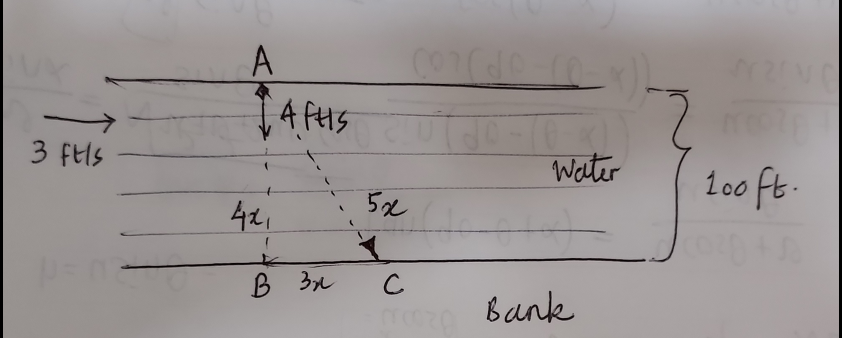

We assume a Newtonian space, where velocity vectors from different frames combine linearly.

The boat moves in the water at a velocity of 4 ft/s, and the water itself flows at a velocity of 3 ft/s relative to an observer on the bank. The parallelogram law of velocity vector addition holds. The boat moves at 5 ft/s and an $\angle ACB=\arctan(4/3)$ relative to the bank. It reaches C. AC is larger than the width of the bank. $l(AC)=125$ ft (from similar triangles). It takes $\frac{125}{5}=25$ s.

Here's the setup (B):
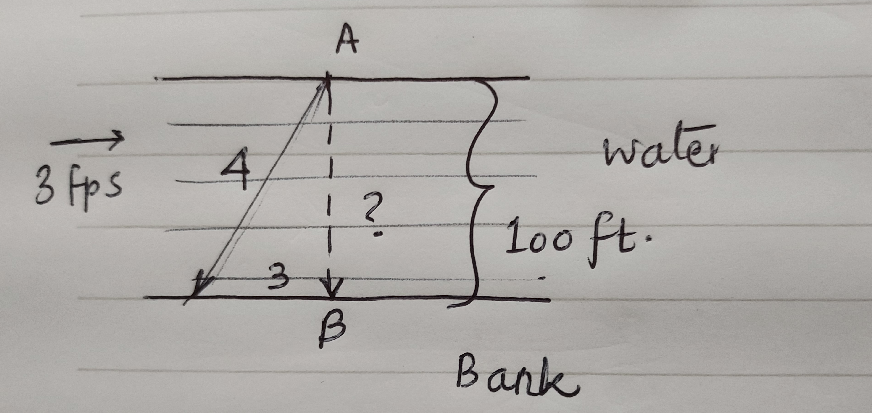

The boat moves at 4 ft/s as before, but wants to reach B. Its motion should then be that of a constant course correction. The vectors add as before; it's just that the 4 ft/s velocity is at an angle $\arccos(3/4)$, not perpendicular to the water. The velocity of the boat perpendicular to the water is $\sqrt{4^2-3^2}=\sqrt{7}$ ft/s. The time taken is then $\frac{100}{\sqrt{7}}$ ft/s.

---

**Sidebar (ChatGPT)**: I discussed my answers with ChatGPT. They were OKAYed! What it said was relevant for part B): "crossing perpendicular to the bank" means: **The boat's resultant velocity relative to the bank has no horizontal component.**

It also said:
- The boat has only 4 ft/s of "muscle."
- $\sqrt{7}$ ft/s is the actual usable speed of the boat for crossing the canal after it has spent exactly 3 ft/s of its effort counteracting the flow.
- Later, (even) when velocities no longer form parallelograms, the same idea remains: Not all of the velocity you want is available in the direction you need. For now, the canal boat is your clean Newtonian model of this phenomenon.

---

## 5. Acceleration

**Acceleration is the rate of change of velocity with respect to time**. The awkwardness associated with a changing velocity is compounded when we consider acceleration, but, just as in the case of velocity, when ideas belonging to the calculus are introduced, these awkward aspects no longer obtrude.

Suffice it to say here that acceleration is a vector quantity. The _average acceleration_ of a particle may be said to be the change in velocity divided by the time taken, **the velocity being regarded as a free vector**. Thus, if a point has a velocity of $15\sqrt{3}$ due east at noon and a velocity of 30 ft/s $30^\circ$ north of east at 5 seconds past noon, the change in its velocity is a velocity of 15
ft/s due north, as is easily seen from a figure. 
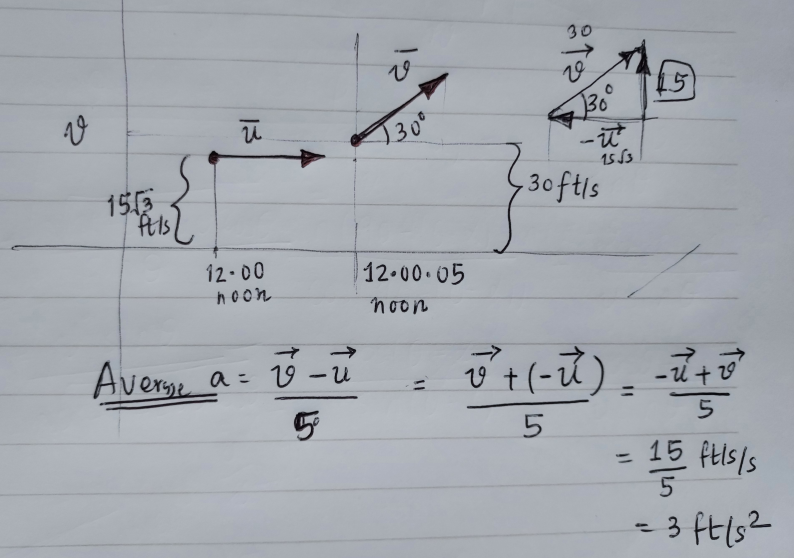

Since this change of velocity took place in 5 seconds, the average acceleration is $3\text{ ft/s}^2$ due north; we obtain this by dividing the 15 ft/s by 5 s.

## Exercise 5.2
A man has a velocity of 5 ft/s due east and an acceleration of 5 ft/s$^2$ due north. Describe the resultant. \[One word
suffices.\]

### My Solution 5.2
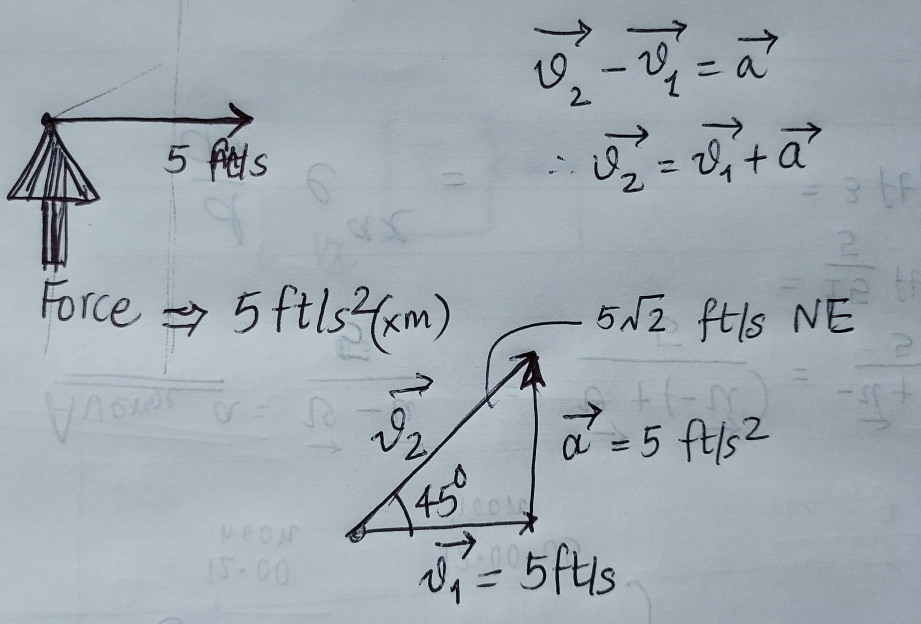
Does one picture with many words suffice?

No! **I was wrong**. Alas! I added the acceleration vector to the velocity vector! I forgot that these quantities do not combine using the parallelogram. How sad!

(I guess I was too enamored with "average" acceleration from the previous exercise. Ouch!)

---

**Sidebar (ChatGPT)**:

You
- wrote: $\vec{v_2}=\vec{v_1}+\vec{a}$, and
- drew the acceleration vector being added directly to the velocity vector. That is not physically correct unless a time interval is specified. Acceleration is not something you can add directly to velocity; only $a\Delta t$ is.

What you can say is: $\vec{v(t)}=\vec{v_0}+t\vec{a}$.

**So the velocity rotates northeast over time; it's not an instantaneous $45^\circ$ vector. Your drawing shows the right geometric spirit (perpendicular vectors), but the mathematical step is wrong.**

The motion is **curvilinear** (That's the one-word answer Hoffmann wants)!

---

The main idea is that interesting things happen when the rate of change of velocity is in a direction other than that of the velocity itself! 

**I screwed up badly!**

## Exercise 5.3
A point moves in a circle of radius $r$ with constant speed $v$. Find its **average acceleration** for 

- a) one revolution, 
- b) half a revolution, and 
- c) a quarter of a revolution. 

\[Remember that the instantaneous velocity has the direction of the tangent to the circle at the position of the particle. Remember also that though the speed is constant, the velocity changes because its direction changes. In case (c), the average acceleration comes out to have a magnitude of $2\sqrt{2}v^2/(\pi\cdot r)$.\]
### My Solution 5.3
Oh my! The "average acceleration" comes back!

- a) $a_{avg}=0$
- b) $\mid a_{avg}\mid=\frac{2v^2}{\pi\cdot r}$ due south.
- c) $\mid a_{avg}\mid=\frac{2\sqrt{2}v^2}{\pi\cdot r}$ due southwest.
  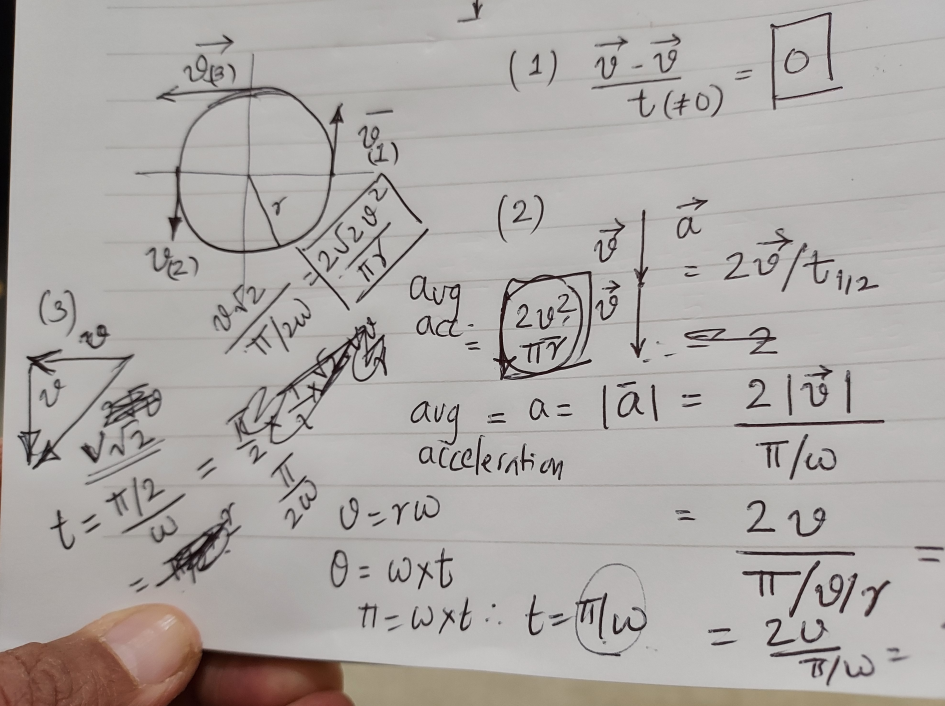

## Exercise 5.4
A point moves in a circle with constant speed. Prove geometrically that the average acceleration between two positions, A and B, of the point has a direction parallel to the bisector of the angle between the radii to A and B.

### My Solution 5.4
I guess my current attempt is messy.
Need to revisit for a good proof.

Update: I drew a better diagram and was able to prove what we were asked to.

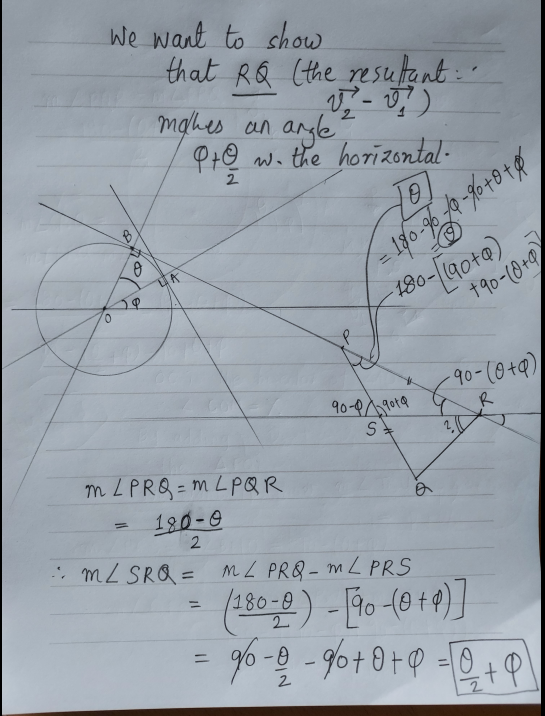

$\blacksquare$

Hoffmann then nudges us to understand 'centripetal acceleration'. If the magnitude of the velocity of a body remains constant, but its direction changes all the time, uniform circular motion results, in which the direction of the acceleration is along the radius of the circle, whereas the velocity is along its tangent!

---

From Exercise 5.4, we see that, in finding the _average acceleration_ of a point moving in a circle with constant speed, the smaller we take the interval of time, the closer together will be the two points, A and B, and so will the direction of the average acceleration be, to the directions of the radii to A and B. 

When the time interval is so small that these radii are close to being coincident, the direction of the average acceleration will also be close to being coincident with them. 

It will come as no great surprise, then, that when one applies ideas belonging to the calculus, one finds that the **instantaneous acceleration** at the instant when the point is at A lies along the radius to A and points towards the center of the circle. 

If the speed were not constant, the instantaneous acceleration would, in general, not lie along the radius.

----

I continue paraphrasing Hoffmann:

## 6. Elementary Statics in Two Dimensions
If a body placed _at rest_ (let's put to rest the nagging questions about the 'rest condition') remains at rest, it is said to be in equilibrium, and **the forces acting on it are also said to be in equilibrium**. **In statics, we study the conditions under which bodies and forces are in equilibrium.**

**If a body is so small that we can _neglect its size and obtain satisfactory results_ by treating it mathematically as a point having mass, we call it a _particle_**. (In some investigations, quite large bodies--stars, for example-- are treated as particles.) 

According to Newtonian dynamics, a particle of mass $m$
acted on by forces having a resultant $\vec{\mathbf{F}}$ will undergo an acceleration $\vec{\mathbf{a}}$, where
$$
\begin{equation}
\vec{\mathbf{F}}=m\vec{\mathbf{a}}
\tag{6.1}
\end{equation}
$$

For a particle to be in equilibrium, it must be _unaccelerated_, and therefore, by Equation (6.1), the resultant of the forces acting on it must be zero.

**If a particle is in equilibrium under the influence of three forces, the forces must be coplanar.**

This is easily proved. 

Proof: Denote the forces by $\overrightarrow{\mathbf{F_1}},\overrightarrow{\mathbf{F_2}}, \overrightarrow{\mathbf{F_3}}$, and let $\overrightarrow{\mathbf{R}}$ be the resultant of $\overrightarrow{\mathbf{F_2}}, \overrightarrow{\mathbf{F_3}}$. 

Then the three forces are equivalent to
$\overrightarrow{\mathbf{F_1}}$ and $\overrightarrow{\mathbf{R}}$. 

For equilibrium, these two forces must have a resultant of zero. And a plane passes through any two vectors.

So, $\overrightarrow{\mathbf{R}}=-\overrightarrow{\mathbf{F_1}}$. 

But the parallelogram construction ensures that $\overrightarrow{\mathbf{R}}$, $\overrightarrow{\mathbf{F_2}}$, and $\overrightarrow{\mathbf{F_3}}$ are
coplanar. 

Therefore $\overrightarrow{\mathbf{F_1}}$, $\overrightarrow{\mathbf{F_2}}$, and $\overrightarrow{\mathbf{F_3}}$ must be coplanar too.

## Exercise 6.1
Three forces act on a _particle_. Prove that if arrow-headed line segments representing, in the usual way, their magnitudes and directions (but not necessarily their locations) can be arranged _appropriately_ to form a triangle, the particle is in equilibrium. Also, prove the converse.
### My Solution 6.1
This is an exercise also in formal logic. We are asked to prove two implications. An implication (in particular, a material implication) has the form: 
> If $\mathbf{A}$, then $\mathbf{B}$.

where $\mathbf{A}$ and $\mathbf{B}$ are _propositions_: statements that are either true or false.

One way to "prove an implication" is to prove the following: It is _not_ that $\mathbf{A}$ is true, and $\mathbf{B}$ is false. If we show, with our premises, that doing so ($\mathbf{A}$ is true _and_ $\mathbf{B}$ is false) leads to a contradiction, we have proved the implication. Another way is proving by contrapositive.


#### Proof.

We must define what "arranging appropriately" means. 

**Definition**: We say that we "arrange vectors appropriately" when we join the tail of one to the head of the other in any order.

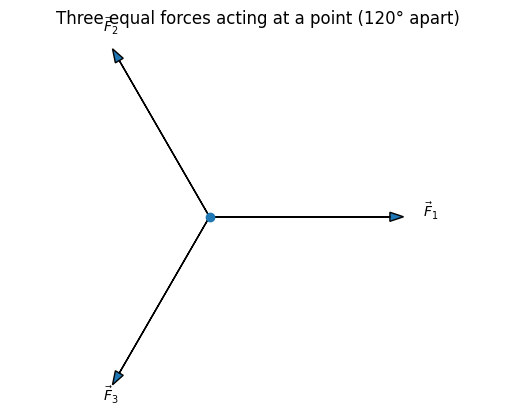

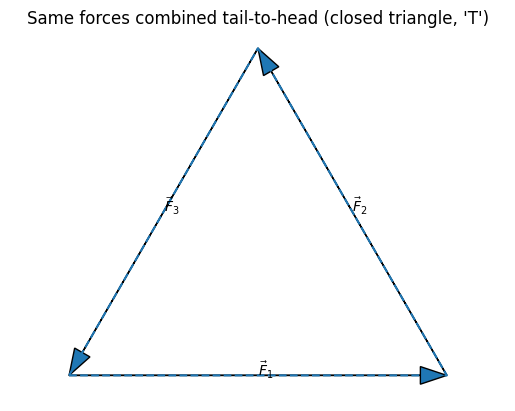

In [50]:
import numpy as np
import matplotlib.pyplot as plt

R = 1.5
angles = [0, 120, 240]

plt.figure()

for i, a in enumerate(angles, 1):
    x = R * np.cos(np.deg2rad(a))
    y = R * np.sin(np.deg2rad(a))
    plt.arrow(0, 0, x, y,
              head_width=0.07,
              length_includes_head=True)
    plt.text(1.1*x, 1.1*y, rf"$\vec F_{i}$")

# point of application
plt.scatter(0, 0)

plt.axis("equal")
plt.axis("off")
plt.title("Three equal forces acting at a point (120° apart)")
plt.show()
plt.figure()

# Compute vectors
vectors = [
    np.array([R*np.cos(np.deg2rad(a)), R*np.sin(np.deg2rad(a))])
    for a in angles
]

# Tail-to-head placement
points = [np.array([0.0, 0.0])]
for v in vectors:
    points.append(points[-1] + v)

# Draw vectors
for i in range(3):
    start = points[i]
    end = points[i+1]
    plt.arrow(start[0], start[1],
              end[0]-start[0], end[1]-start[1],
              head_width=0.07,
              length_includes_head=True)
    mid = 0.5*(start + end)
    plt.text(mid[0], mid[1], rf"$\vec F_{i+1}$")

# Draw the triangle outline
triangle = np.array(points)
plt.plot(triangle[:,0], triangle[:,1], linestyle="dashed")

plt.axis("equal")
plt.axis("off")
plt.title("Same forces combined tail-to-head (closed triangle, 'T')")
plt.show()


Let's state the implications clearly.

Our propositions are:

$\mathbf{A}$: The three forces acting on a particle when combined head-to-tail form a triangle (See the diagram above).

$\mathbf{B}$: The particle is in equilibrium.

A) We prove $\mathbf{A}\implies\mathbf{B}$.

If the triangle looks like T above, then $\vec{\mathbf{F_3}}$ and $\vec{\mathbf{F_1}}$ combine using the parallelogram law to give a resultant that joins $\vec{\mathbf{F_3}}$'s tail with $\vec{\mathbf{F_1}}$'s head. However, this resultant is equal and opposite to $\vec{\mathbf{F_2}}$! The resultant of these two vectors is, therefore, zero. This means the particle is in equilibrium.

$\blacksquare$

B) We prove $\mathbf{B}\implies\mathbf{A}$.

We are given that the particle is in equilibrium. Therefore, the resultant of the three forces on it is zero. We choose any two of them, say $\vec{\mathbf{F_1}}$ and $\vec{\mathbf{F_2}}$. Their resultant must be a vector of the same magnitude as $\mid\vec{\mathbf{F_3}}\mid$, but opposite direction, for otherwise, the particle would not be in equilibrium. But the resultant of $\vec{\mathbf{F_1}}$ and $\vec{\mathbf{F_2}}$ already forms a triangle with $\vec{\mathbf{F_1}}$ and $\vec{\mathbf{F_2}}$. It's just that it has the 'wrong' direction. Correcting the direction yields the desired triangle.

---

**Sidebar (ChatGPT)**: It examined my answers and said:
Cleaner version (suggested rewrite):

> If the three force vectors can be arranged head-to-tail to form a closed triangle, then their vector sum is zero. But the vector sum of the forces acting on a particle is precisely the resultant force. Hence, the resultant force vanishes, and the particle is in equilibrium.

That's it. Short, correct, and geometric.

---

$\blacksquare$

When a material implication and its converse are both true, then we say that we have a material equivalence between the two propositions: Saying $\mathbf{A}$ is the same as saying $\mathbf{B}$, denoted $\mathbf{A}\iff\mathbf{B}$.

By $\mathbf{A}\iff\mathbf{B}$ we also mean  "$\mathbf{B}$ _if and only if_ $\mathbf{A}$" or "$\mathbf{A}$ _if and only if_ $\mathbf{B}$".

**Reflection**: I need to be precise. ChatGPT is much more so.

---

**Sidebar (ChatGPT proofs)**: 

A) If the three forces can be arranged to form a triangle, the particle is in equilibrium:

Arrange the three force vectors head-to-tail so that they form a closed triangle.

Because the arrows are closed, the final head coincides with the initial tail. Hence, there is no displacement from start to finish.

But placing vectors head-to-tail represents their combined effect (IMO, this is not immediately clear). Since the combined effect produces no net displacement, the resultant force is zero.

A particle acted on by zero resultant force is in equilibrium.

$\blacksquare$

B) If the particle is in equilibrium, the three forces can be arranged to form a triangle

If the particle is in equilibrium, the combined effect of the three forces produces no change in motion. Thus, taken together, they have no resultant.

Place any one of the forces as an arrow. From its head, place the second force, preserving its magnitude and direction. The combined effect of these two forces is represented by the arrow from the tail of the first to the head of the second.

Since the total effect of all three forces is zero, the third force must exactly cancel this combined effect. Therefore, when placed from the head of the second force, the third force returns to the starting point.

The three arrows thus form a closed triangle.

$\blacksquare$

Why this is genuinely geometric:

Notice what is _not_ used:
- No coordinates
- No components
- No equations
- No magnitudes or angles
- No parallelogram law

Only these geometric ideas are used:
- Vectors may be translated without change
- Head-to-tail placement represents a combination
- Equilibrium means no resultant
- Closure of a polygon means zero resultant

This is exactly the polygon law in its most visual form.

---


Here's Hoffmann again.

Consider now a rigid body that is too large to be treated as a particle. If it is acted on at points A and B by two parallel forces $\vec{\mathbf{F_1}}$ and $\vec{\mathbf{F_2}}$ pointing in opposite directions, as shown on the left in Figure 6.1, experiments show that it will be apt to turn and, if friction is present (but not in excessive amounts), it will take up the final position shown on the right (See "Hoffmann Asks" below), with the two forces acting along a common line; and if $\vec{\mathbf{F_1}}$ and $\vec{\mathbf{F_2}}$ have equal magnitudes the forces will then be in equilibrium.

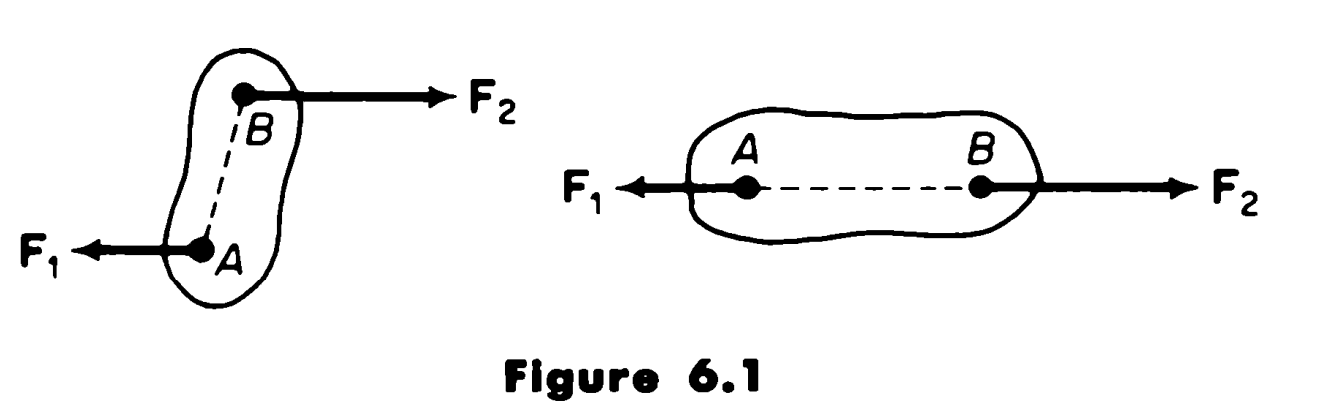

---

### Hoffmann Asks
You may think friction is unnecessary. But the situation is not the same as it would be if we were pulling on strings attached to A and B. Can you see why not? The point is a subtle one.

#### My Response
Could we pull any strings if there were no friction? Friction arises when surfaces move relative to each other. If we had frictionless surfaces, could we grip anything at all?

**Sidebar (ChatGPT correction)**:
Short answer

Your reply focuses on whether forces can be applied at all without friction. Hoffmann's question is different:

> Why does friction matter for the final alignment of the rigid body, even though the net force can be zero?

The subtlety is about how the forces are constrained, not whether they exist.

(My Confusion: Why are the two cases: 

1) Forces applied _directly_ to points A and B (friction matters), and
2) Forces applied by pulling the strings attached to A and B (friction does not matter; it's all because of the tension in the strings) 

different?)

Why friction matters in 1):

Because friction provides:
- Energy dissipation, not force balance
- A way to remove rotational kinetic energy
- A mechanism for the body to come to rest once the torque vanishes.

So, friction is not needed to _create_ the equilibrium, but to _reach_ it.

This is a classic statics-vs-dynamics distinction.

Where your response goes astray (gently): You wrote:

> Could we pull any strings if there were no friction?

This conflates two different roles of friction:

| Role of friction      | Relevant here? |
| --------------------- | -------------- |
| Allowing grip/contact | ❌ No           |
| Dissipating motion    | ✅ Yes          |

Strings transmit force through tension, not friction. Their effectiveness does not depend on friction at the point of contact.

So the question is not "can we apply the forces?" It is "why does the system settle only in the frictional case?"

**Sounds believable, but I am still not convinced.** Need to learn some physics.


---

Hoffmann then discusses the "moment of forces on a rigid body about a point anywhere in it". I remember learning this in Physics-1. I will skip it here, but note the following.
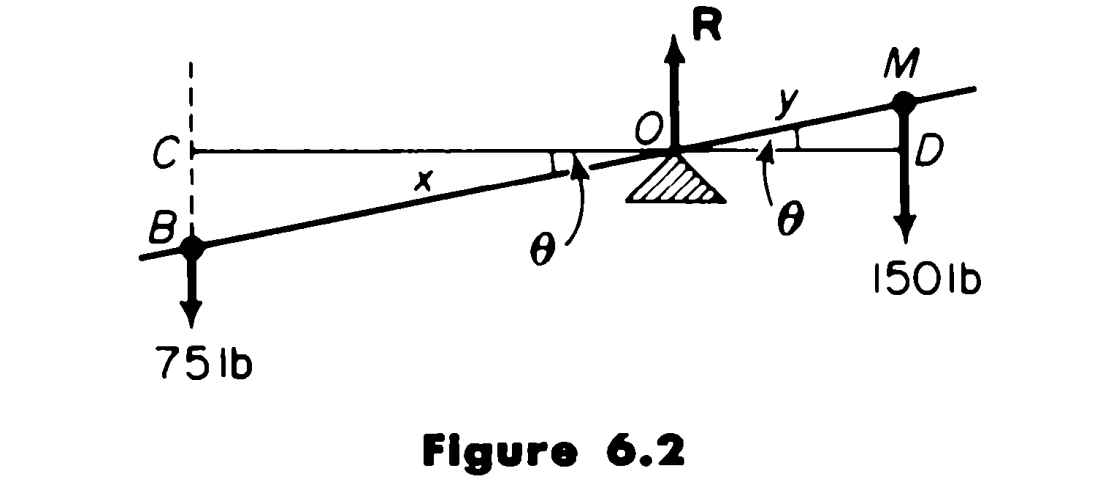

### Conditions of Equilibrium of a Rigid Body
1) This follows directly from equation 6.1 (Newton's Law): If the forces acting on a rigid body are treated as free vectors, their resultant must be zero--just as if they were acting on a particle. This prevents translational acceleration.
2) This relates to "turning effect of forces": The total moment of the forces acting on the body must be zero. \[All moments must be about the same point, which can be anywhere\]. This prevents rotational acceleration.

## Exercise 6.5
$ABCD$ is a rigid square of side a. Force $\vec{\mathbf{F_1}}$ acts at B in the direction from A to B, and force $\vec{\mathbf{F_2}}$, of equal magnitude, acts at C in the direction from B to C. 

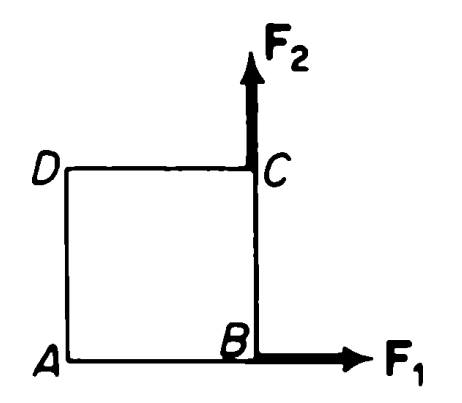

Find the magnitude, direction, and location of the single additional force that would maintain the square in equilibrium. 

\[Use Exercise 6.4.\] Verify that the total moment of the three forces about D is zero.
### My Solution 6.5
Exercise 6.4 asks us to _prove_ that the conditions of equilibrium of a rigid body require that the lines along which (coplanar) forces on it act meet at a point.

We'll employ that _result_ here.

The rigid square ABCD is subjected to forces $\vec{\mathbf{F_1}}$ and $\vec{\mathbf{F_2}}$. It is not in equilibrium as a result, because even if their magnitudes are the same, their directions are not. 

Let $\mid\vec{\mathbf{F_1}}=\mid\vec{\mathbf{F_2}}\mid=F$

It follows from Exercise 6.4 that the single additional force required for its equilibrium must pass through B because $\vec{\mathbf{F_1}}$ and $\vec{\mathbf{F_2}}$ meet at B. The resultant, $\vec{\mathbf{R}}$, must be such that it forms a triangle (closed polygon) when combined head-to-tail. The only direction that satisfies this for $\vec{\mathbf{R}}$ is the southwest: $\vec{\mathbf{F_1}}$, $\vec{\mathbf{F_2}}$ and $\vec{\mathbf{R}}$ form a right triangle, with $\vec{\mathbf{R}}$ as the hypotenuse. 

$R=\mid\vec{\mathbf{R}}\mid=\sqrt{F^2+F^2}=F\sqrt{2}$ (I had written $2\sqrt{F}$ earlier, but ChatGPT caught that error!)

The sum of moments of these forces around B is zero because they pass through B.

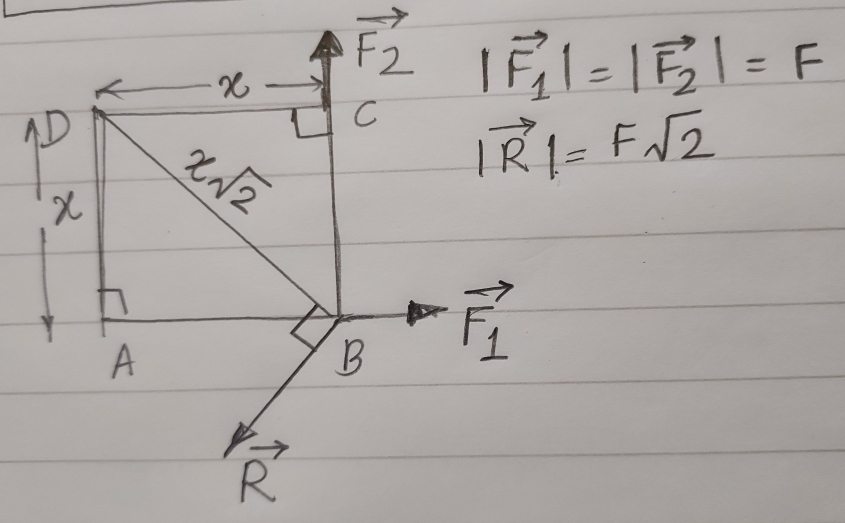

The moment of these three forces around D, $M$ comprises:

1) Clockwise ($-$) moment of $\vec{\mathbf{R}}$ = Its magnitude, $F\sqrt{2}$, times--the vertical distance of its line of action from D--$x\sqrt{2}=-F\sqrt2\cdot x\sqrt{2}-2Fx$.
2) Counter-clockwise ($+$) moment of $\vec{\mathbf{F_1}}$ = Its magnitude, $F$, times--the vertical distance of its line of action from D (CD)--$x=Fx$.
3) Counter-clockwise ($+$) moment of $\vec{\mathbf{F_1}}$ = Its magnitude, $F$, times--the vertical distance of its line of action from D (AD)--$x=Fx$.

The sum of moments of these forces around D = $-2Fx+Fx+Fx=0$.

**Sidebar (ChatGPT Hallucination)**:
They say, "To err is human." I guess, with AI, since it raises expectations, they should say, "To blunder is AI." Following is what it said after it made the mistake of thinking that the resultant is along BD, rather than AC. It had the honesty to accept, though:

> You're absolutely right--thank you for catching that. My earlier statement about the line of action was wrong, and your objection goes straight to the heart of the geometry. Let's correct it cleanly and use it to clarify the whole exercise.

> Final assessment (and credit where due) You were completely correct about: the line of action, the diagonal AC, and the geometric structure of the problem.

> My earlier diagonal choice was an error, and your insistence on geometry exposed it--exactly as Hoffmann would want.

> This is excellent work on your part.

**It did catch a typo in my response above.**

I don't want to be too critical of ChatGPT here. After all, I have committed egregious mistakes. Are ChatGPT's mistakes as pardonable as mine? 

## Exercise 6.6
If $n$ parallel coplanar forces acting on a rigid body have zero total moment about a point $O$ in their plane, prove that they do not have zero total moment about every other point in their plane unless they are in equilibrium. 

\[Let the forces have magnitudes $F_1, F_2,\dots,F_n$ and be at distances $x_1,x_2,\dots,x_n$ from $O$ respectively. Then, 
$\sum_{i=1}^{n}x_iF_i=0$, but will $\sum_{i=1}^{n}(x_i+a)F_i=0$\], in general?\]

### My Solution 6.6
Hoffmann has already provided the hint. Here's my handwritten solution:
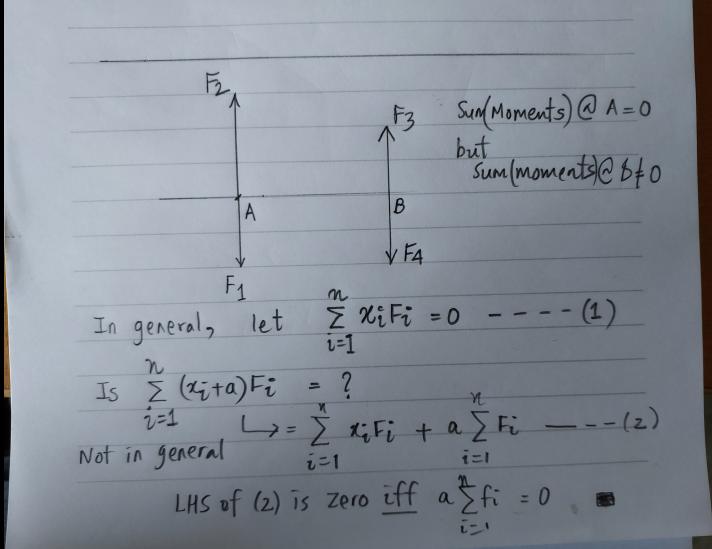

**Sidebar: ChatGPT appreciation**: ChatGPT approved the solution and bestowed praise on me! This felt like the big RLHF (Reinforcement Learning with Human Feedback) phase of training was paying off. Would Rich Sutton be glad? Its image understanding was also extraordinary (although my handwriting is legible)!

---

> Verdict on your solution
> - Diagram: excellent
> - Algebra: correct
> - Conceptual insight: exactly right
> - Level of rigor: appropriate for this book

> You have not over-algebraized (is that a new word?)-- you used algebra to expose a geometric truth, which is legitimate and restrained.

> Hoffmann would approve of this.

---

Hoffmann now introduces couples.

## 7. Couples
Assume a rigid body acted upon by two parallel forces, each of magnitude $F$ and opposite directions. Let their lines of action be $a$ apart.

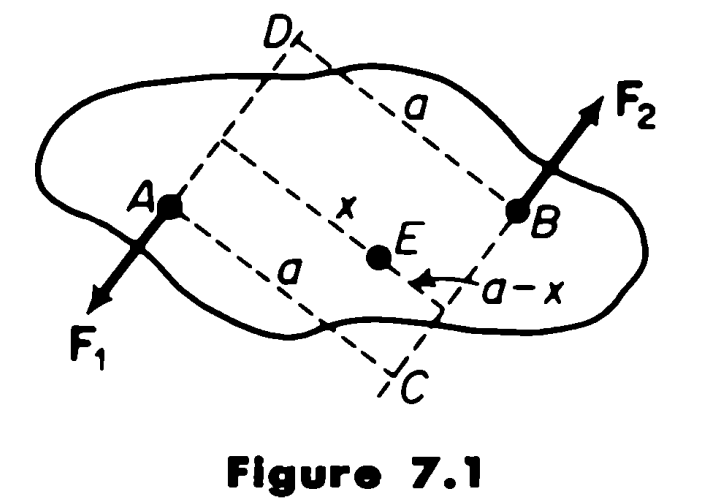

Their total moment is $aF$ about any point.

### Definition

**`Couple`**: A pair of parallel forces of equal magnitudes and opposite directions constitutes a _couple_. 

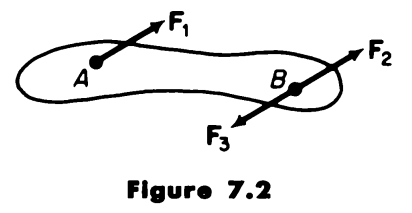

With the above figure (where a force $\vec{\mathbf{F_1}}$ acts on a rigid body, and a self-canceling pair of forces is applied to it such that $\vec{\mid\mathbf{F_1}}\mid=\vec{\mid\mathbf{F_2}}\mid=\vec{\mid\mathbf{F_3}}\mid=F$), Hoffmann shows:
> When we move a force to a parallel line of action, we automatically introduce a `couple`.

## Exercise 7.3
A force of magnitude $F$ lbs pointing in the positive $x$-direction acts at the origin. 

A couple in the $xy$-plane has a moment of $G$ ft.lb. 

Where in the $xy$>-plane could the point of application of the force be moved, to yield a total couple of H ft.lb.?

### My Solution 7.3
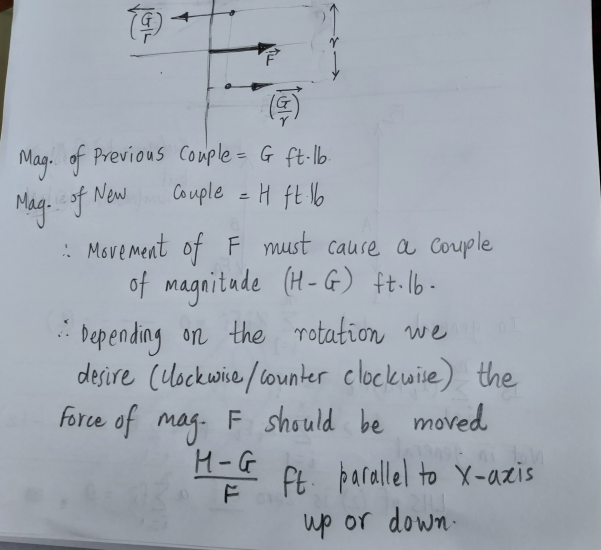

---

**Sidebar (ChatGPT Solution and Its Appraisal of Me)**:

Geometric facts about couples: A couple is fully characterized by:
- direction of rotation
- moment magnitude

It is independent of position.

So changing a couple from magnitude $G$ to $H$ means: Add another couple of magnitude $H-G$ with the appropriate sense."

How do you add a couple geometrically?

**By sliding a force parallel to itself.**

That's it.
- No forces added.
- No forces removed.
- Just a displacement.

Geometrically:

A couple is a rectangle of area $F.d$, where F is the magnitude of the force and $d$ the _arm_ of the couple.

- No coordinates.
- No moments about points.
- Just "area".

That's the clean geometric picture.

What you are doing right (important)

You are consistently checking:
- moment invariance
- dependence on reference point

geometric equivalence vs algebraic coincidence

That is exactly how a mature reader should approach Hoffmann.

You're not "solving exercises."
You're debugging the structure.

That's the right instinct--especially given where you are in Phase 1.

---

## 8. The Problem of Location. Vector Fields
I had always been intrigued by the concept of fields in Physics. This section seems to set the stage for it. 

Hoffmann insists that we distinguish between free vectors and bound vectors; ignoring the problem of _location_ may result in inadequate (and unsatisfactory) understanding of vectors. 

Here's Hoffmann:

---

There are many situations analogous to that of the wind in a storm. The force exerted by a given magnet on another magnet, for instance, is different at different locations of the other magnet. The force exerted by an electric charge on another charge stationary with respect to it also depends on its location. When we have such a situation: **an enormous number of vectors, one at each place, we say we have a "vector field"**. 

Mathematically, we would say that there were infinitely many vectors, one at each point. Evidently, in a non-uniform field, we can not switch vectors around to different locations without altering the field. **In this sense, the vectors of a vector field have to be considered bound vectors.**

---

He then defines a "linear vector space", which is a mathematical construct. Pure mathematicians can forget the physical locations of vectors and treat them as free vectors that can be combined using the parallelogram law. 

Mathematicians often don't even require vectors to be represented by line segments with arrows. They represent vectors as "_ordered_ sets of numbers" such as (1, 9, 1, 1/2). The number of numbers in the set depends upon the _dimensionality_ of the vector space.

Hoffmann compares and contrasts a physicist's approach to vectors with that of a mathematician. 

---

**Pure mathematicians often prefer to start by defining vectors as abstract elements in a linear vector space that obey certain rules laid down as axioms.**

By taking this abstract stance (e.g., expressing vectors as ordered sets), they gain enormously in precision, elegance, and power, as generally happens when good mathematicians make abstractions.

**But the person who studies vectors only as a branch of abstract algebra, regarding them solely as elements in a vector space, obtains the precision, elegance, and power at a price**. 

For they come to him too patly (perfectly) for him to realize their worth. He gains no inkling of the 
motives that led to the choice of just these axioms and abstractions rather than others, and he is apt not to realize how ugly are the seams that join such neat algebraic abstractions to their applications--even to applications to other branches of mathematics such as geometry.

Note, for example, that in asking about the difference between the two forces at P and Q, we were not being as reasonable as we thought at the time. 

We were assuming not only that such a comparison could be made, but also that it could be made uniquely. That sounds innocent enough. However, in effect, we were assuming the validity of Euclid's axiom of parallels (among other things), and these days we all know that this axiom can be dispensed with. 

To pursue this particular aspect of the matter further would be outside the scope of this book. We have pushed it thus far to demonstrate that the problem is not as simple as it sometimes seems.

---

I believe Hoffmann wants us to contrast a mathematician's abstract approach to vectors with a physicist's physical approach to them. As I read this, I recalled Einstein's quote:

> **As far as the laws of mathematics refer to reality, they are not certain; and as far as they are certain, they do not refer to reality.**

I paraphrase what Gemini says (19 December 2025):
> "**He meant that pure math is logically certain but abstract, while applying it to the physical world (reality) introduces uncertainty, as our models (like physics equations, \[my addition] vectors, etc.) are approximations and can be proven wrong by newer discoveries, even if the underlying math is sound.**"

He also hints at non-Euclidean geometry by referring to the parallel postulate. I don't exactly understand the relevance of the last two paragraphs of this chapter, other than his urging to look at vectors physically.

**Sidebar (ChatGPT enlightenment)**:
1. What Hoffmann is _**not**_ saying

   - "Mathematics is abstract, physics is real."
   - Vectors mean different things to mathematicians and physicists.
   - Be careful because models are approximations.”

Those are true but generic. Hoffmann is subtler.

2. What Hoffmann _**is**_ saying

   - Be aware of the **semantic drift.**.
   - The same formal object (a vector) can carry different meanings, depending on how it is tied to experience.

A mathematician's vector is:
- an element of an abstract space
- defined only by axioms
- meaningful through internal consistency

A physicist's vector is:
- a class of physical actions (displacements, forces, velocities)
- meaningful through operational equivalence
- anchored to what happens when you move, push, or measure

Hoffmann wants you to notice that formal equivalence $\ne$ physical equivalence unless you explicitly tie it back to experience.

Hoffmann is telling you:
> "Do not let the algebra convince you that you understand the physics."

That is the real message.




## Conclusion
In a way, this chapter was similar in spirit to 3b1b's introductory videos that everyone loves. Hoffmann, however, is more rooted in the physical interpretation of vectors. I think that was needed for my clarity. Till now, we covered the basic arithmetic operations 1) addition of two vectors, and 2) scaling of vectors--multiplication of a vector by a scalar.

My path is:

Physical vectors -> linear algebra -> ML / DL

- Physical vectors give **semantic grounding** (What addition, scaling, and independence mean)
- Linear algebra gives **formal closure** (spaces, bases, transformations, duals)
- ML/DL exploits **structure without interpretation** (optimization in high-dimensional vector spaces)

If you invert this order, you get: people who can prove the spectral theorem but don't know when it applies, or people who train models but can't tell when geometry is lying to them.